In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("accident_prediction_india.csv")

In [3]:
df.head()

,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,...,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,...,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,...,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,...,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,...,Urban Road,Wet,Dusk,Signs,115,30,Male,NaN,No,Intersection


In [4]:
df.tail()

,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
2995,Tamil Nadu,Chennai,2021,January,Sunday,1:15,Minor,5,Truck,4,...,National Highway,Wet,Dark,Signs,74,43,Male,Expired,Yes,Intersection
2996,Uttarakhand,Unknown,2018,July,Sunday,10:12,Fatal,3,Car,3,...,Urban Road,Under Construction,Daylight,NaN,86,23,Female,NaN,Yes,Intersection
2997,Meghalaya,Unknown,2021,January,Thursday,19:34,Minor,2,Two-Wheeler,8,...,National Highway,Dry,Dark,Signs,47,57,Female,Valid,Yes,Intersection
2998,Meghalaya,Unknown,2023,June,Sunday,20:54,Fatal,1,Cycle,9,...,Urban Road,Under Construction,Daylight,Signs,60,28,Female,Expired,Yes,Bridge
2999,Arunachal Pradesh,Unknown,2020,September,Monday,7:19,Fatal,5,Cycle,1,...,National Highway,Under Construction,Daylight,NaN,40,66,Male,NaN,Yes,Bridge


In [5]:
df.shape

(3000, 22)

In [6]:
df.columns

Index(['State Name', 'City Name', 'Year', 'Month', 'Day of Week',
       'Time of Day', 'Accident Severity', 'Number of Vehicles Involved',
       'Vehicle Type Involved', 'Number of Casualties', 'Number of Fatalities',
       'Weather Conditions', 'Road Type', 'Road Condition',
       'Lighting Conditions', 'Traffic Control Presence', 'Speed Limit (km/h)',
       'Driver Age', 'Driver Gender', 'Driver License Status',
       'Alcohol Involvement', 'Accident Location Details'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   State Name                   3000 non-null   object
 1   City Name                    3000 non-null   object
 2   Year                         3000 non-null   int64 
 3   Month                        3000 non-null   object
 4   Day of Week                  3000 non-null   object
 5   Time of Day                  3000 non-null   object
 6   Accident Severity            3000 non-null   object
 7   Number of Vehicles Involved  3000 non-null   int64 
 8   Vehicle Type Involved        3000 non-null   object
 9   Number of Casualties         3000 non-null   int64 
 10  Number of Fatalities         3000 non-null   int64 
 11  Weather Conditions           3000 non-null   object
 12  Road Type                    3000 non-null   object
 13  Road Condition               3000

In [8]:
df.describe()

,Year,Number of Vehicles Involved,Number of Casualties,Number of Fatalities,Speed Limit (km/h),Driver Age
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000
mean,2020.530000,2.996000,5.066000,2.455333,74.940667,44.17700
std,1.683858,1.428285,3.214097,1.717650,26.765088,15.40286
min,2018.000000,1.000000,0.000000,0.000000,30.000000,18.00000
25%,2019.000000,2.000000,2.000000,1.000000,51.000000,31.00000
50%,2021.000000,3.000000,5.000000,2.000000,75.000000,45.00000
75%,2022.000000,4.000000,8.000000,4.000000,99.000000,57.00000
max,2023.000000,5.000000,10.000000,5.000000,120.000000,70.00000


In [9]:
df.isnull().sum()

State Name                       0
City Name                        0
Year                             0
Month                            0
Day of Week                      0
Time of Day                      0
Accident Severity                0
Number of Vehicles Involved      0
Vehicle Type Involved            0
Number of Casualties             0
Number of Fatalities             0
Weather Conditions               0
Road Type                        0
Road Condition                   0
Lighting Conditions              0
Traffic Control Presence       716
Speed Limit (km/h)               0
Driver Age                       0
Driver Gender                    0
Driver License Status          975
Alcohol Involvement              0
Accident Location Details        0
dtype: int64

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(include=np.number):
    df[col] = df[col].fillna(df[col].median())

In [12]:
for col in df.columns:
    print(f"{col} : {df[col].nunique()}")

State Name : 32
City Name : 28
Year : 6
Month : 12
Day of Week : 7
Time of Day : 1263
Accident Severity : 3
Number of Vehicles Involved : 5
Vehicle Type Involved : 7
Number of Casualties : 11
Number of Fatalities : 6
Weather Conditions : 5
Road Type : 4
Road Condition : 4
Lighting Conditions : 4
Traffic Control Presence : 3
Speed Limit (km/h) : 91
Driver Age : 53
Driver Gender : 2
Driver License Status : 2
Alcohol Involvement : 2
Accident Location Details : 4


In [13]:
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month

State Name
Goa                  109
Sikkim               108
Delhi                108
Uttarakhand          106
Jammu and Kashmir    105
Name: count, dtype: int64


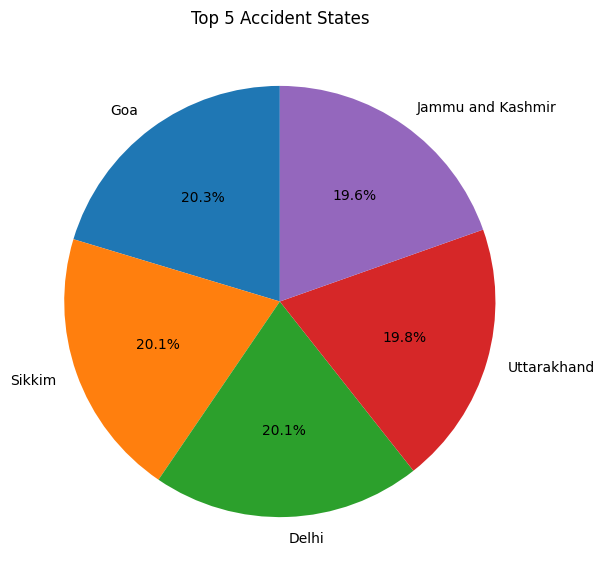

In [14]:
df.columns = df.columns.str.strip()

if 'State Name' in df.columns:
    top_states = df['State Name'].value_counts().head(5)

    print(top_states)

    plt.figure(figsize=(7,7))
    plt.pie(
        top_states.values,
        labels=top_states.index,
        autopct='%1.1f%%',
        startangle=90
    )
    plt.title("Top 5 Accident States")
    plt.show()
else:
    print("State Name column not found")

In [15]:
cat_cols = df.select_dtypes(include='object').columns

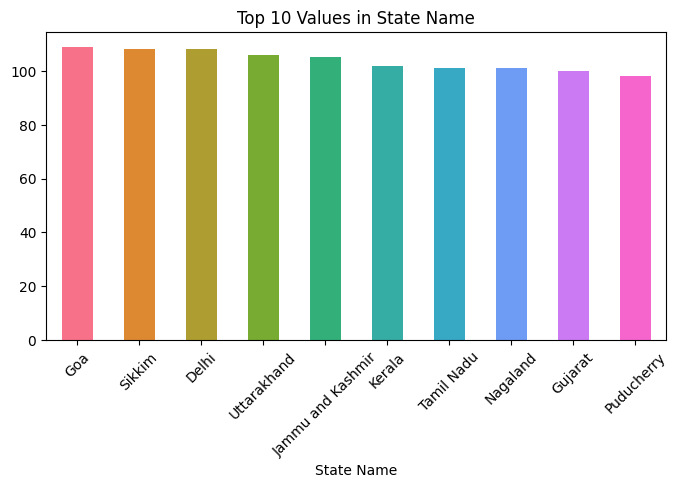

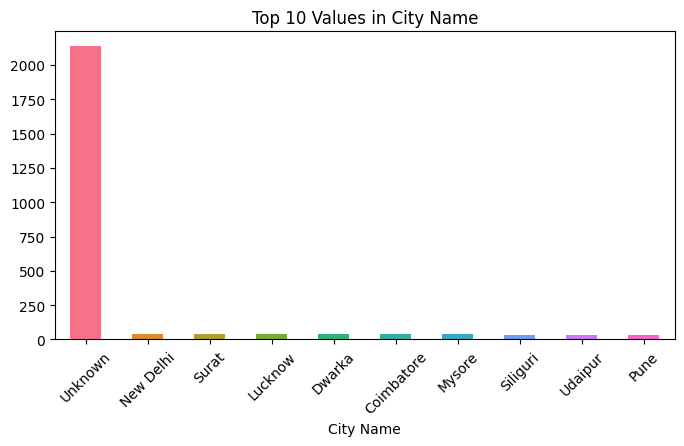

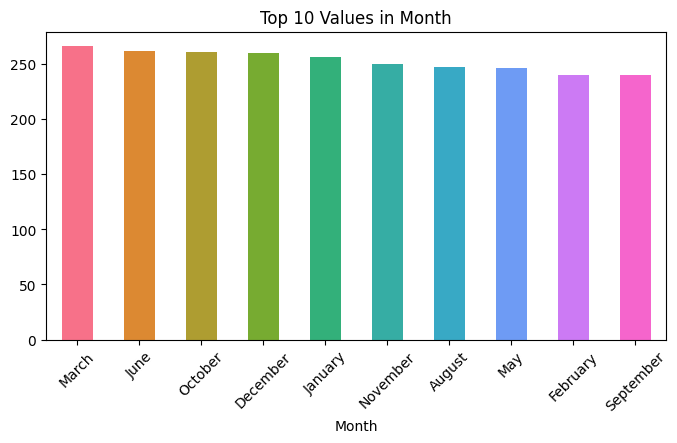

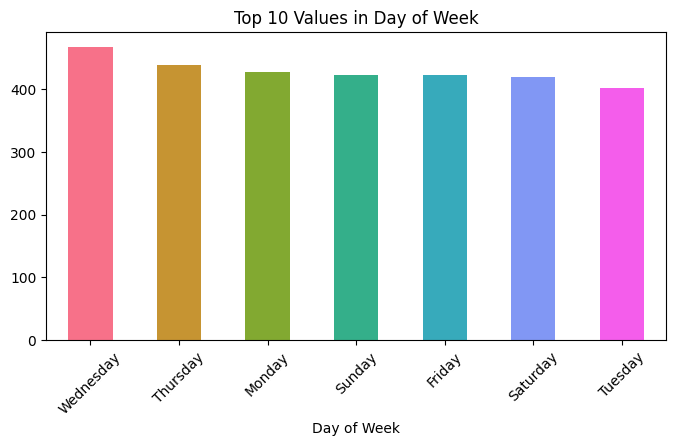

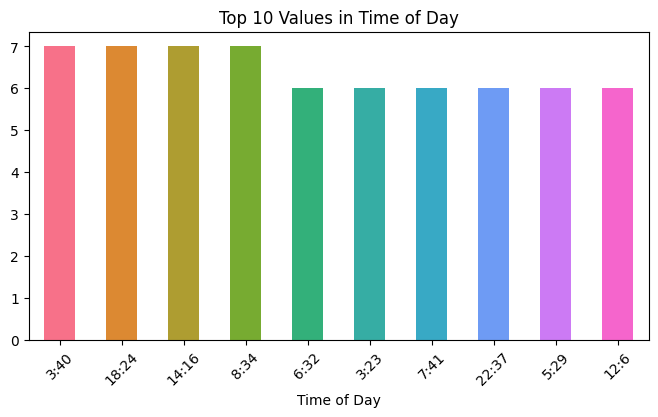

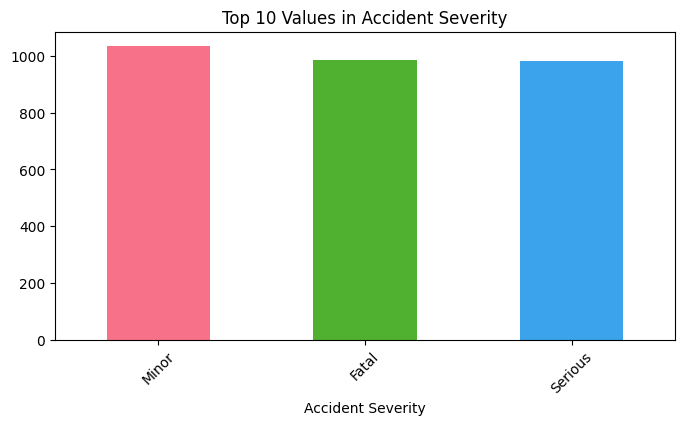

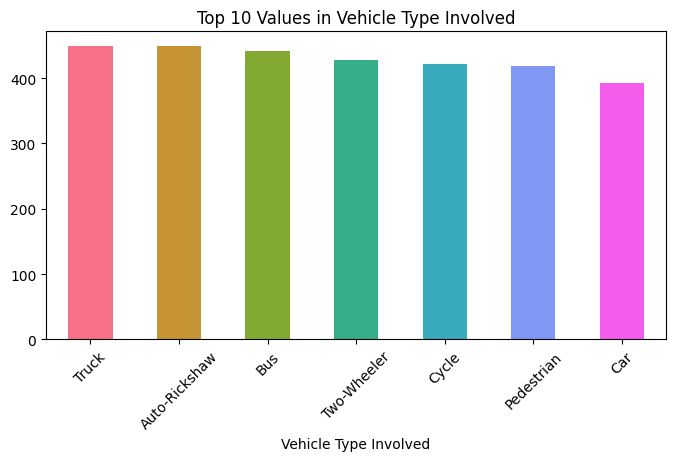

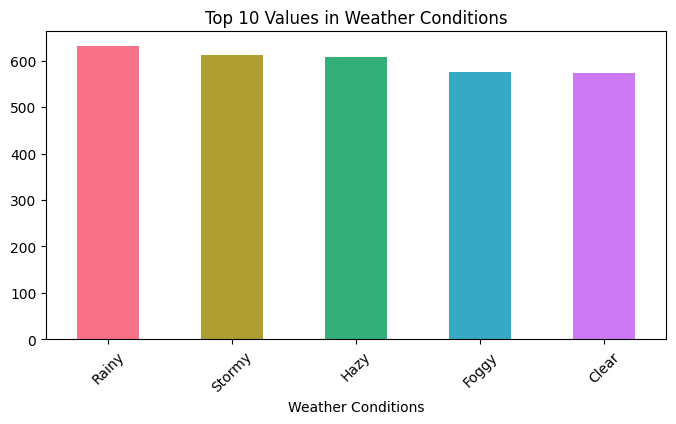

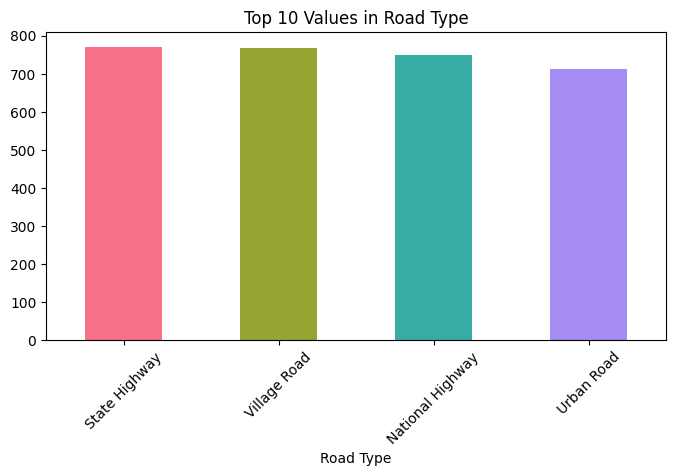

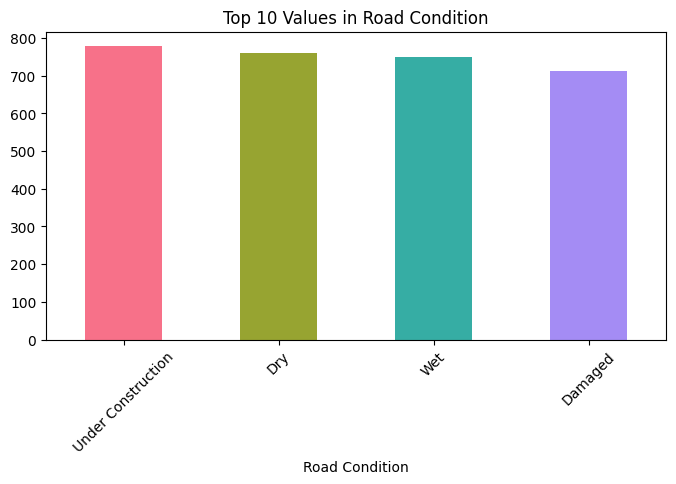

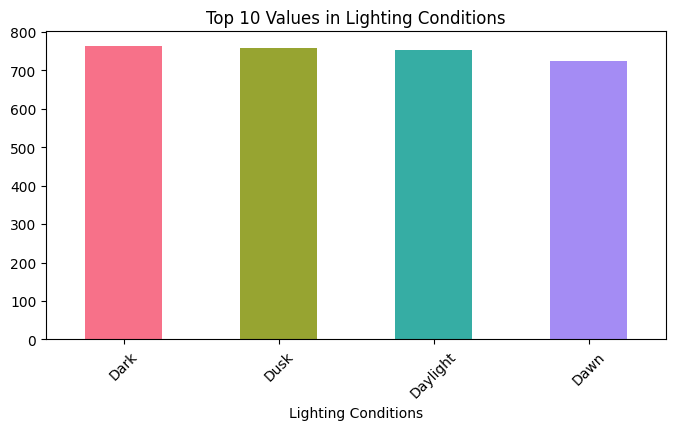

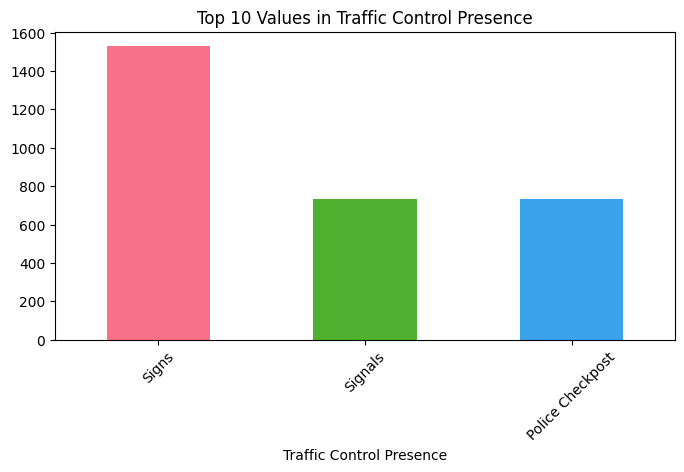

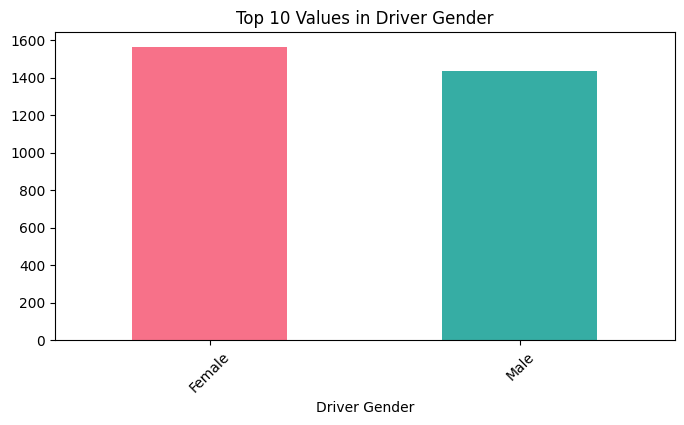

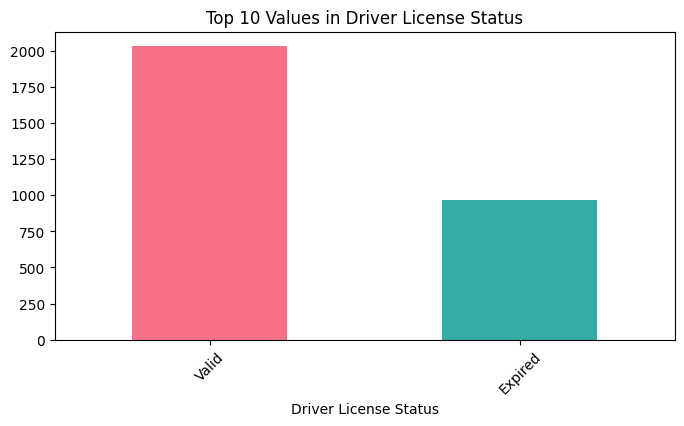

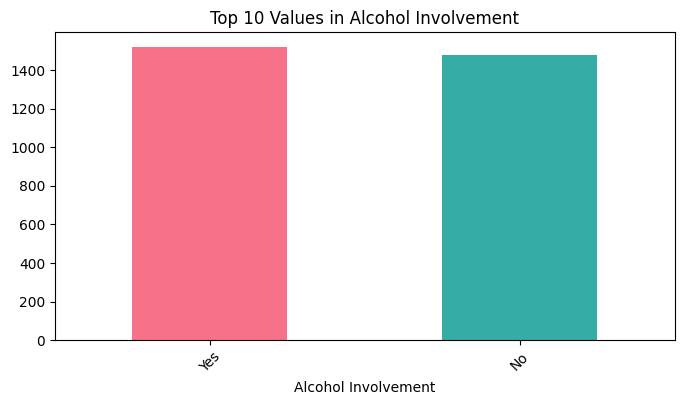

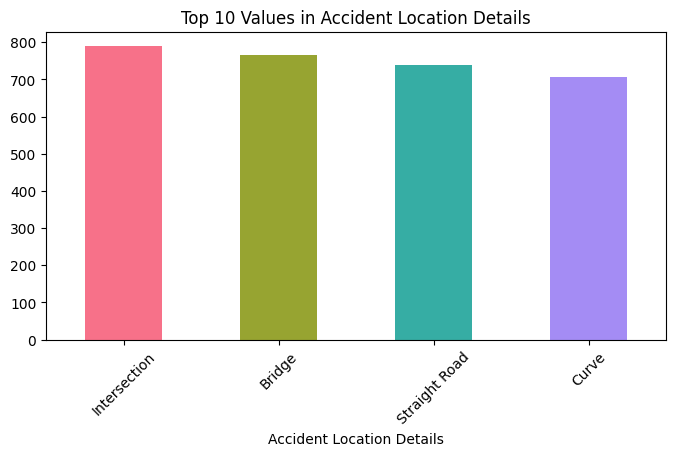

In [16]:
import seaborn as sns

for col in cat_cols:
    plt.figure(figsize=(8,4))

    data = df[col].value_counts().head(10)

    colors = sns.color_palette("husl", len(data))

    data.plot(kind='bar', color=colors)

    plt.xticks(rotation=45)
    plt.title(f"Top 10 Values in {col}")
    plt.show()


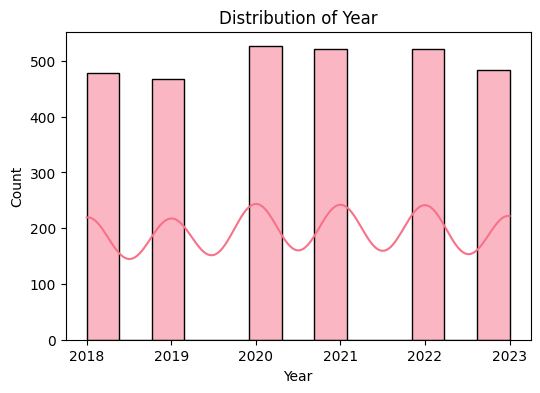

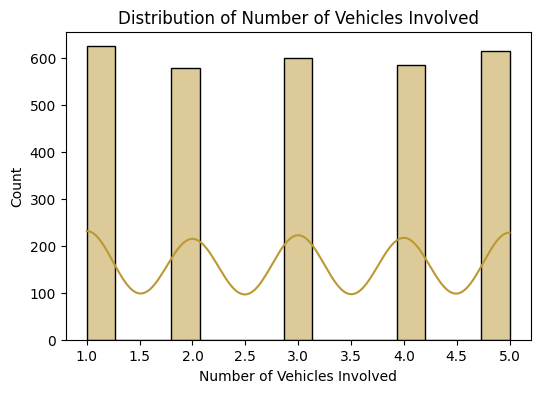

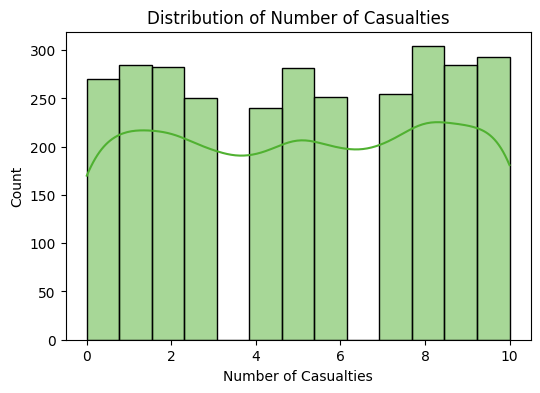

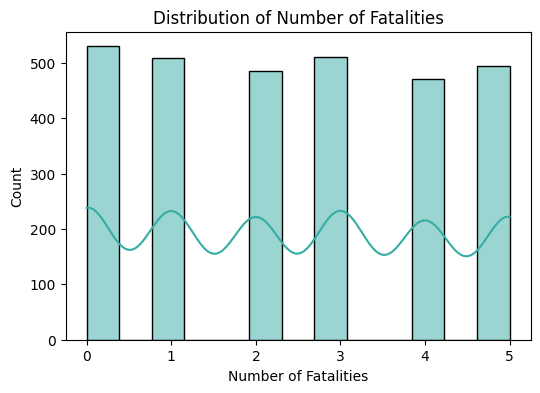

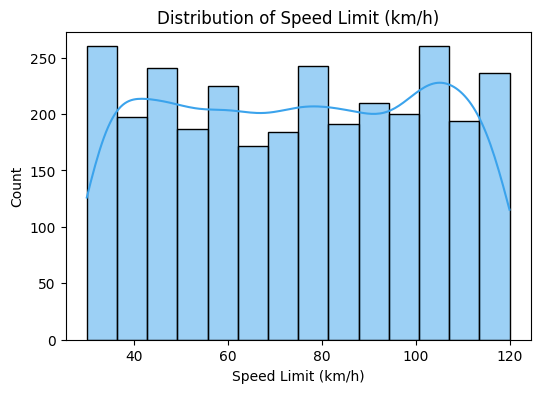

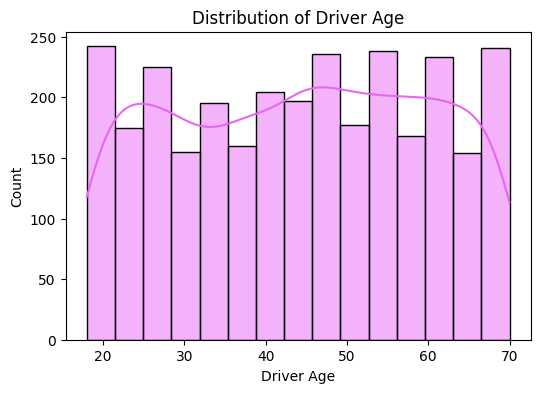

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include='number').columns

palette = sns.color_palette("husl", len(num_cols))

for i, col in enumerate(num_cols):
    plt.figure(figsize=(6,4))
    
    sns.histplot(df[col], kde=True, color=palette[i])
    
    plt.title(f"Distribution of {col}")
    plt.show()

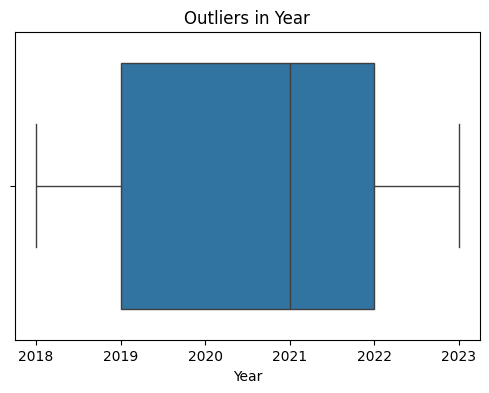

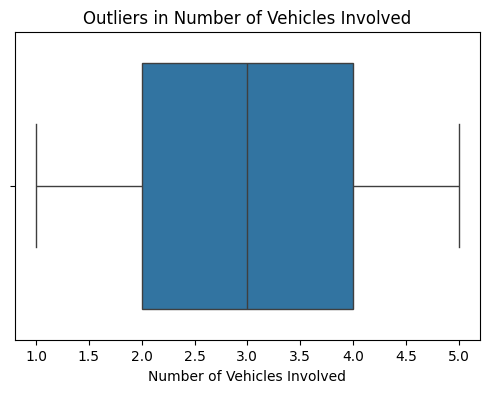

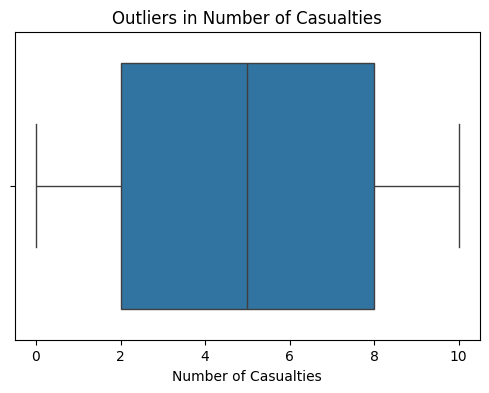

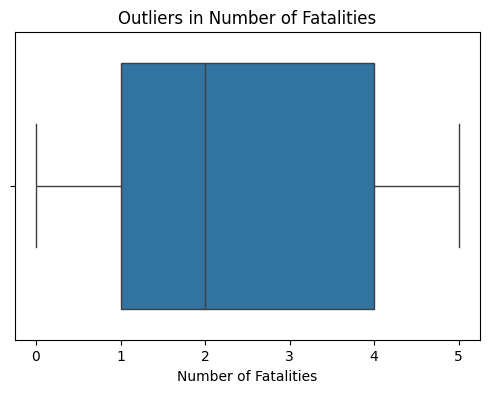

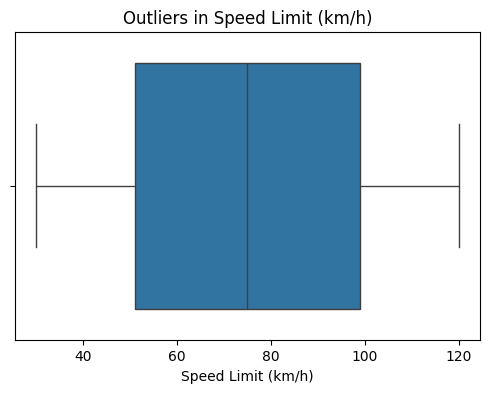

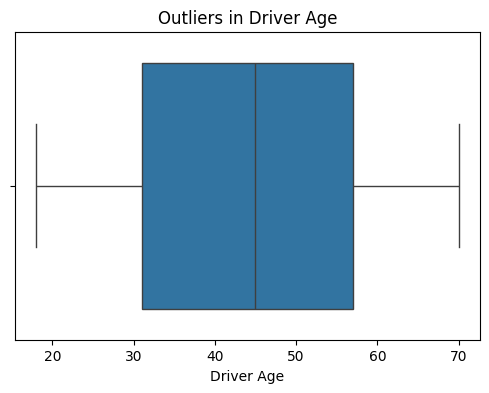

In [20]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()


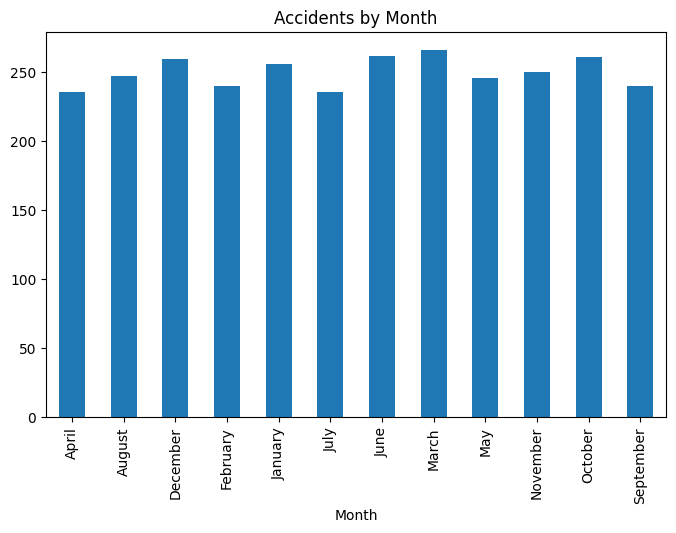

In [21]:
if 'Month' in df.columns:
    monthly = df['Month'].value_counts().sort_index()

    plt.figure(figsize=(8,5))
    monthly.plot(kind='bar')
    plt.title("Accidents by Month")
    plt.show()

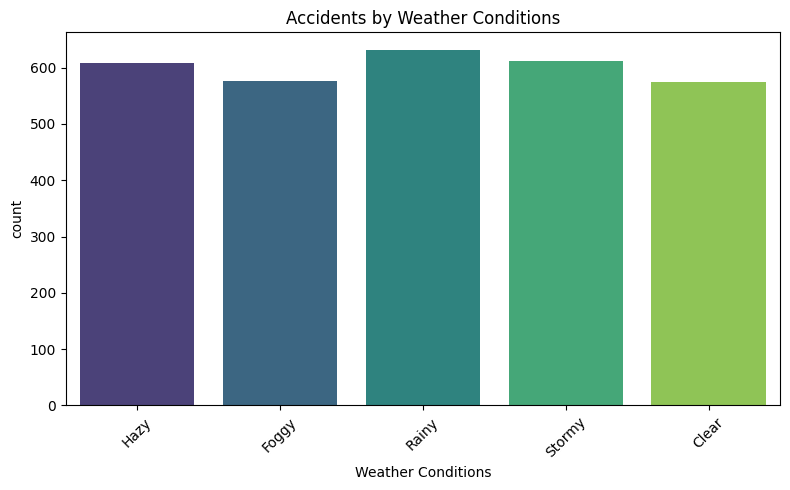

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

df.columns = df.columns.str.strip()

col_name = None

if 'Weather Conditions' in df.columns:
    col_name = 'Weather Conditions'
elif 'Weather_Conditions' in df.columns:
    col_name = 'Weather_Conditions'

if col_name:
    df[col_name] = df[col_name].fillna("Unknown")

    if df[col_name].nunique() > 0:
        plt.figure(figsize=(8,5))

        sns.countplot(
            x=col_name,
            data=df,
            hue=col_name,
            palette='viridis',
            legend=False
        )

        plt.xticks(rotation=45)
        plt.title("Accidents by Weather Conditions")
        plt.tight_layout()
        plt.show()
    else:
        print("Column has no valid data")
else:
    print("Weather column not found")

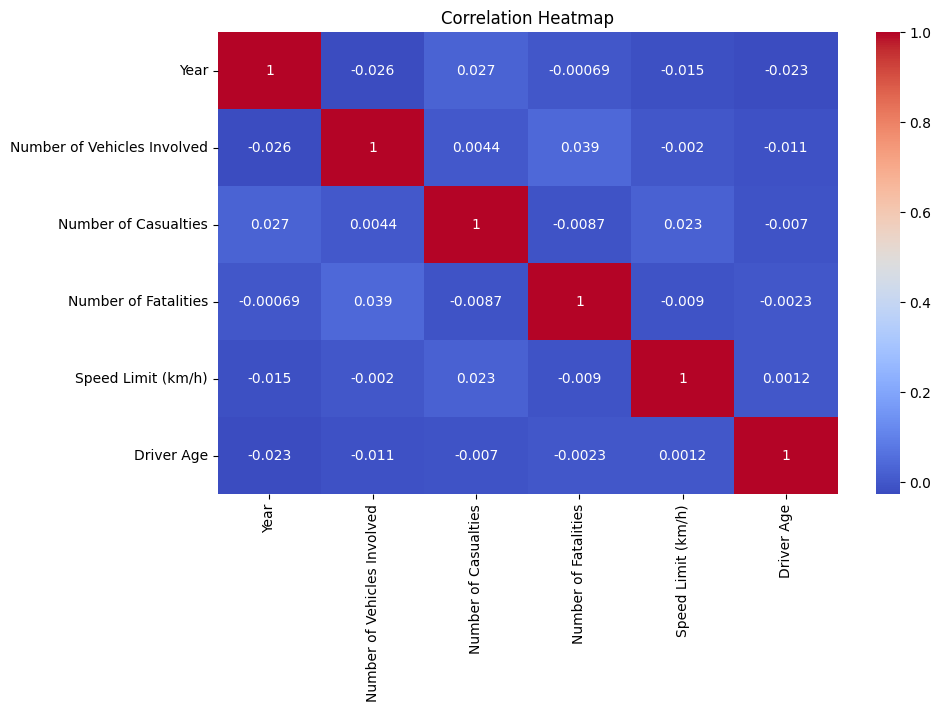

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [24]:
if 'State' in df.columns:
    state_analysis = df.groupby('State').size().sort_values(ascending=False).head(10)
    print(state_analysis)

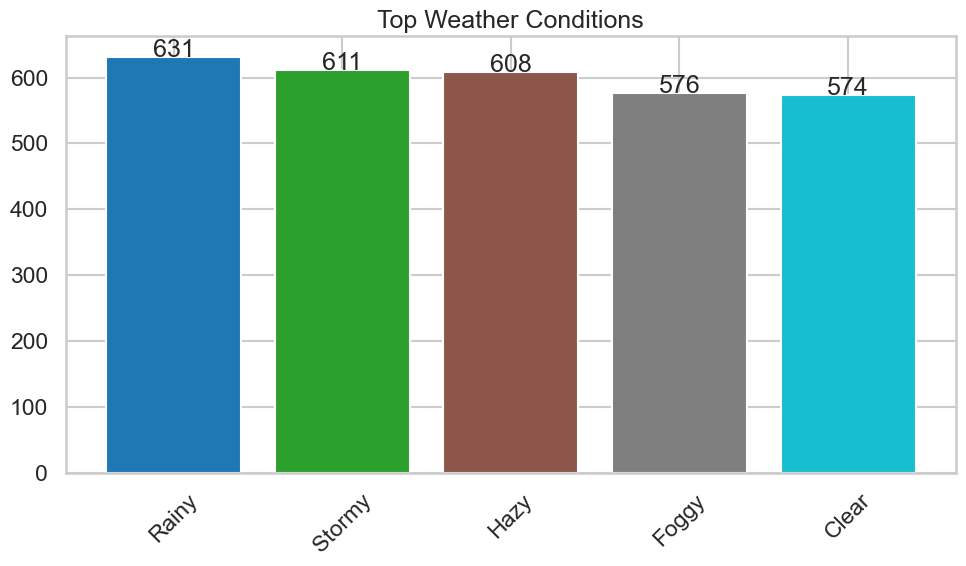

In [54]:
sns.set_style("whitegrid")
df.columns = df.columns.str.strip().str.replace(" ", "_")
if 'Weather_Conditions' in df:
    d = df['Weather_Conditions'].fillna("Unknown").value_counts().head(10)
    plt.figure(figsize=(10,6))
    bars = plt.bar(d.index, d.values, color=plt.cm.tab10(np.linspace(0,1,len(d))))
    for b in bars:
        plt.text(b.get_x()+b.get_width()/2, b.get_height(), int(b.get_height()), ha='center')
    plt.xticks(rotation=45)
    plt.title("Top Weather Conditions")
    plt.tight_layout()
    plt.show()

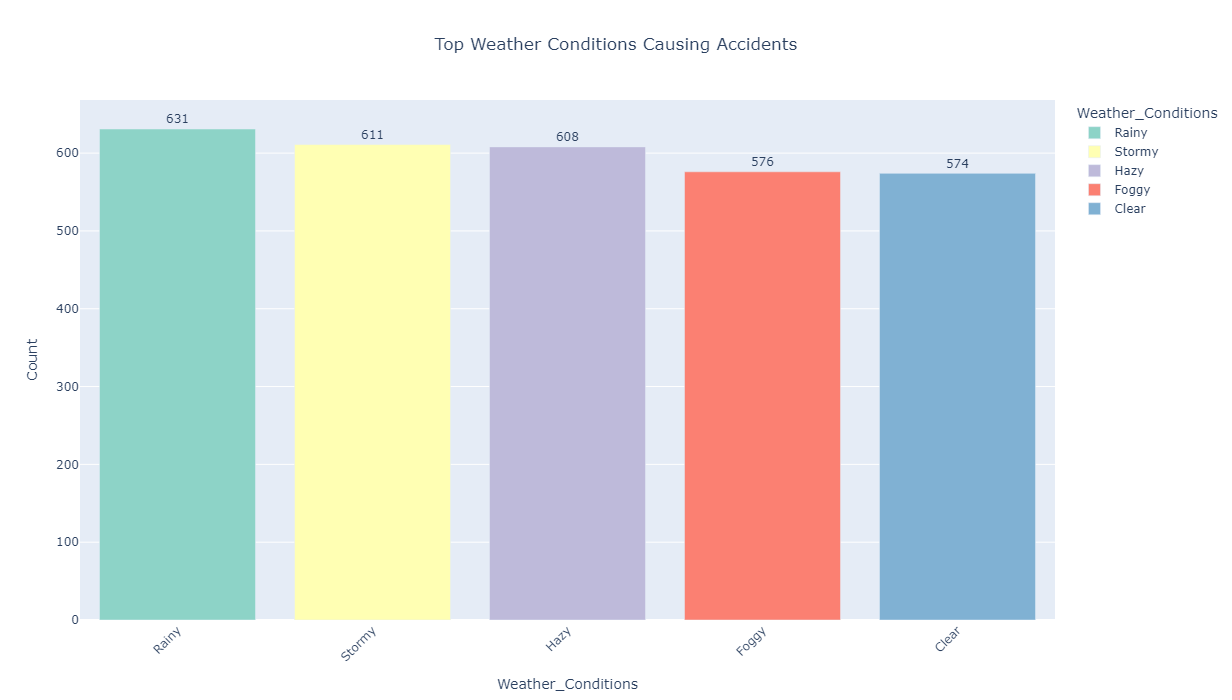

In [53]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
if 'Weather_Conditions' in df:
    d = df['Weather_Conditions'].fillna("Unknown").value_counts().head(10).reset_index()
    d.columns = ['Weather_Conditions','Count']
    fig = px.bar(d, x='Weather_Conditions', y='Count', color='Weather_Conditions',
                 text='Count', color_discrete_sequence=px.colors.qualitative.Set3,
                 title="Top Weather Conditions Causing Accidents", width=1200, height=700)
    fig.update_layout(xaxis_tickangle=-45, title_x=0.5)
    fig.update_traces(textposition='outside')
    fig.show()

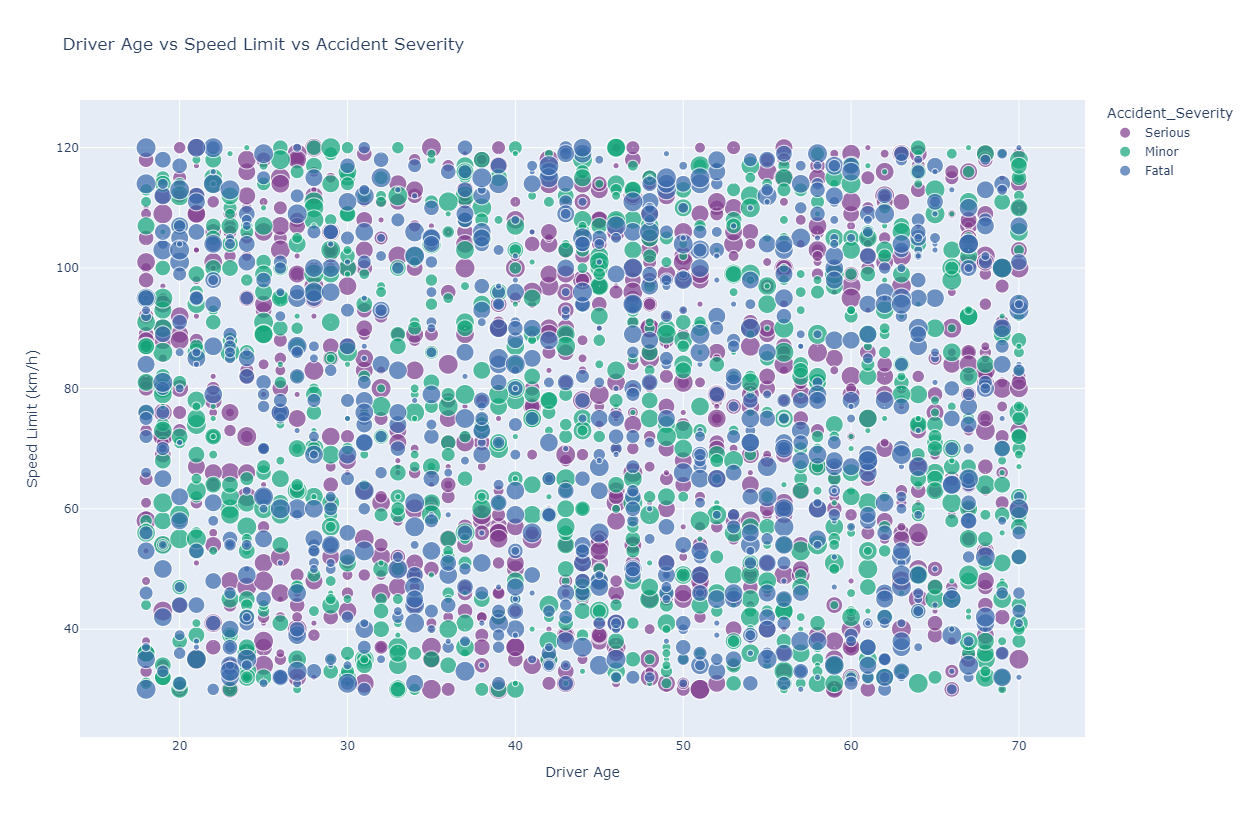

In [51]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
if all(col in df.columns for col in ['Driver_Age','Speed_Limit_(km/h)','Number_of_Casualties','Accident_Severity']):
    fig = px.scatter(df,x='Driver_Age',y='Speed_Limit_(km/h)',size='Number_of_Casualties',color='Accident_Severity',hover_data=['Vehicle_Type_Involved','Weather_Conditions'],title="Driver Age vs Speed Limit vs Accident Severity",color_discrete_sequence=px.colors.qualitative.Bold,width=1300,  height=800)
    fig.update_layout(
        xaxis_title="Driver Age",
        yaxis_title="Speed Limit (km/h)"
    )
    fig.show()
else:
    print("Required columns not found")

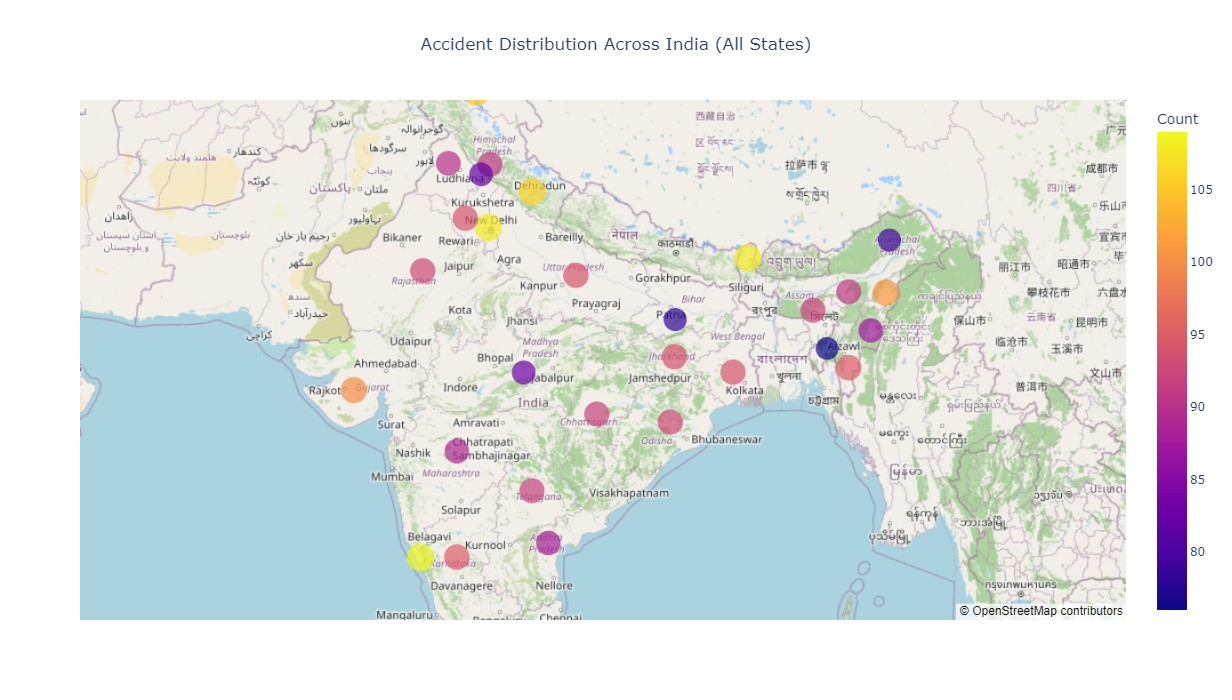

In [42]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("accident_prediction_india.csv")

df.columns = df.columns.str.strip().str.replace(" ", "_")

state_coords = {
    "Andhra Pradesh": (15.9129, 79.7400),
    "Arunachal Pradesh": (28.2180, 94.7278),
    "Assam": (26.2006, 92.9376),
    "Bihar": (25.0961, 85.3131),
    "Chhattisgarh": (21.2787, 81.8661),
    "Goa": (15.2993, 74.1240),
    "Gujarat": (22.2587, 71.1924),
    "Haryana": (29.0588, 76.0856),
    "Himachal Pradesh": (31.1048, 77.1734),
    "Jharkhand": (23.6102, 85.2799),
    "Karnataka": (15.3173, 75.7139),
    "Kerala": (10.8505, 76.2711),
    "Madhya Pradesh": (22.9734, 78.6569),
    "Maharashtra": (19.7515, 75.7139),
    "Manipur": (24.6637, 93.9063),
    "Meghalaya": (25.4670, 91.3662),
    "Mizoram": (23.1645, 92.9376),
    "Nagaland": (26.1584, 94.5624),
    "Odisha": (20.9517, 85.0985),
    "Punjab": (31.1471, 75.3412),
    "Rajasthan": (27.0238, 74.2179),
    "Sikkim": (27.5330, 88.5122),
    "Tamil Nadu": (11.1271, 78.6569),
    "Telangana": (18.1124, 79.0193),
    "Tripura": (23.9408, 91.9882),
    "Uttar Pradesh": (26.8467, 80.9462),
    "Uttarakhand": (30.0668, 79.0193),
    "West Bengal": (22.9868, 87.8550),

    "Delhi": (28.7041, 77.1025),
    "Jammu and Kashmir": (33.7782, 76.5762),
    "Ladakh": (34.1526, 77.5770),
    "Chandigarh": (30.7333, 76.7794),
    "Puducherry": (11.9416, 79.8083),
    "Andaman and Nicobar Islands": (11.7401, 92.6586),
    "Dadra and Nagar Haveli and Daman and Diu": (20.1809, 73.0169),
    "Lakshadweep": (10.5667, 72.6417)
}

if 'State_Name' in df.columns:
    data = df['State_Name'].value_counts().reset_index()
    data.columns = ['State_Name', 'Count']

    data['lat'] = data['State_Name'].map(lambda x: state_coords.get(x, (None, None))[0])
    data['lon'] = data['State_Name'].map(lambda x: state_coords.get(x, (None, None))[1])

    data = data.dropna()

    fig = px.scatter_map(
        data,
        lat='lat',
        lon='lon',
        size='Count',
        color='Count',
        hover_name='State_Name',
        zoom=4,
        title="Accident Distribution Across India (All States)",
        width=1200,
        height=700
    )

    fig.update_layout(
        map_style="open-street-map",
        dragmode=False,
        title_x=0.5
    )

    fig.show()
else:
    print("State_Name column not found")

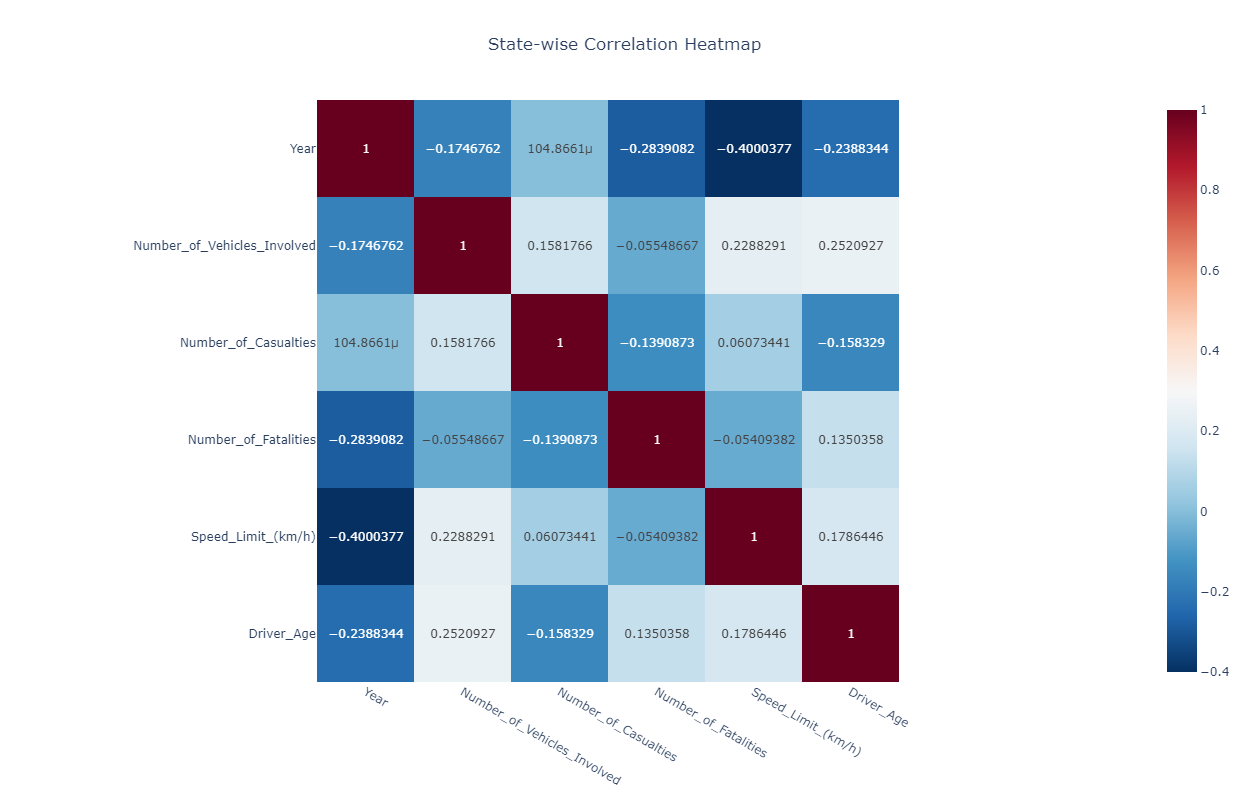

In [50]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
if 'State_Name' in df.columns:
    num_cols = df.select_dtypes(include='number').columns
    state_data = df.groupby('State_Name')[num_cols].mean()
    corr = state_data.corr()
    fig = px.imshow(corr,text_auto=True,color_continuous_scale='RdBu_r',title="State-wise Correlation Heatmap",width=1000,height=800)
    fig.update_layout(title_x=0.5)
    fig.show()
else:
    print("State_Name column not found")

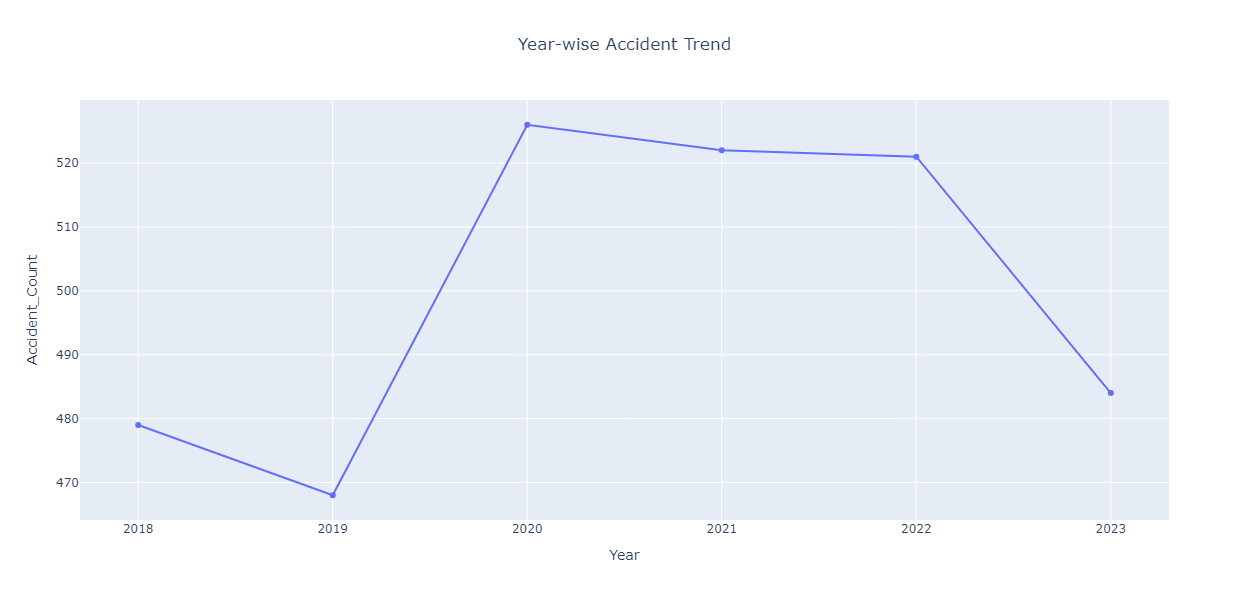

In [48]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

if 'Year' in df:
    fig = px.line(
        df.groupby('Year').size().reset_index(name='Accident_Count'),
        x='Year',
        y='Accident_Count',
        markers=True,
        title="Year-wise Accident Trend",
        width=1100,
        height=600
    )
    fig.update_layout(title_x=0.5)
    fig.show()
else:
    print("Year column not found")

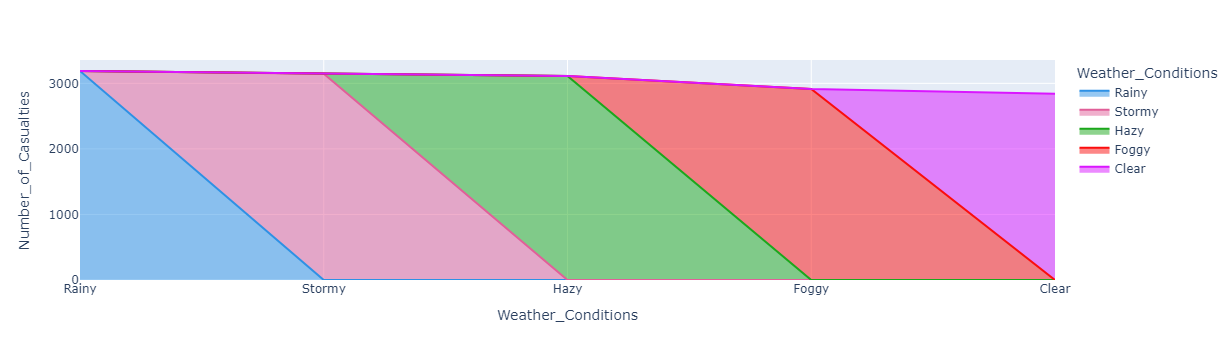

In [47]:
fig = px.area(
    data,
    x='Weather_Conditions',
    y='Number_of_Casualties',
    color='Weather_Conditions',
    color_discrete_sequence=px.colors.qualitative.Dark24
)

fig.show()

In [29]:
df.head()

,State_Name,City_Name,Year,Month,Day_of_Week,Time_of_Day,Accident_Severity,Number_of_Vehicles_Involved,Vehicle_Type_Involved,Number_of_Casualties,...,Road_Type,Road_Condition,Lighting_Conditions,Traffic_Control_Presence,Speed_Limit_(km/h),Driver_Age,Driver_Gender,Driver_License_Status,Alcohol_Involvement,Accident_Location_Details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,...,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,...,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,...,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,...,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,...,Urban Road,Wet,Dusk,Signs,115,30,Male,NaN,No,Intersection
